# Resampling and Logistic Regression

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ElementsOfDataScience/blob/master/examples/resample_logit.ipynb)

Different ways of computing sampling distributions -- and the statistics derived from them, like standard errors and confidence intervals -- yield different results. None of them are right or wrong; rather, they are based on different modeling assumptions. In practice, the differences are often small compared to other sources of error, so we are free to use whichever is convenient.

This article is prompted by a recent question on [Reddit](https://www.reddit.com/r/statistics/comments/10ayfm5/q_parametric_bootstrap_for_logistic_regression/):

> I am trying to do parametric bootstrap for logistic regression but I don't know what the random error terms should be. I know how to do it with linear regression since the error terms follow a normal distribution. Really appreciate any pointers to resources about this topic.

One of the responses recommends [this paper](https://www.scirp.org/journal/paperinformation.aspx?paperid=70962): Isaac Akpor Adjei1 and Rezaul Karim, "An Application of Bootstrapping in Logistic Regression Model".

The paper suggests two ways to compute the sampling distribution of the parameters of a logistic regression by bootstrap sampling. They characterize one as parametric and the other as non-parametric, and advise:

> The non-parametric bootstrap [relies] on weaker assumptions (or no assumptions at all) about the underlying distribution of the population. Statistical practitioners should use non-parametric procedures only in so far as the assumptions about the underlying distribution are seriously doubtful in their validity. ... However, when assumptions are not violated, non-parametric procedures will usually have greater variance (in point estimation), less power (in hypothesis testing), wider intervals (in confidence interval estimation), lower probability of correct selection (in ranking and selection) and higher risk (in decision theory) when compared to a corresponding parametric procedure (Efron and Tibshirani, 1994 [1] ).

The premise of this advice is that the parametric and non-parametric methods are answering the same question in different ways, and that one might be preferred over the other because the results are preferable in one way or another. It is also based on the assumption that the sampling distribution of the parameters -- and the statistics derived from it -- are uniquely and objectively defined.

I disagree with these premises. The parametric and non-parametric methods they present are based on different modeling decisions, so they compute answers to different questions.
And the models they are based on are only two of many possible models.

To explain what I mean, I will implement the methods they propose and explain the assumptions each is based on. Then I will propose a third method that is a hybrid of the two. I'll show that all three methods yield different results, and suggest criteria for when one might be preferred over the others.

## The Data

As an example, I'll use data from the General Social Survey (GSS).
I'll download an HDF file from the *Elements of Data Science* repository, which contains a subset of the GSS data that has been resampled to correct for stratified sampling.

In [1]:
from os.path import basename, exists

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bernoulli
import statsmodels.formula.api as smf

np.random.seed(42)

In [2]:


def download(url):
    filename = basename(url)
    if not exists('../data/'+filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
    
download('https://github.com/AllenDowney/' +
         'ElementsOfDataScience/raw/master/data/gss_eda.hdf')

In [3]:
gss = pd.read_hdf('../data/gss_eda.hdf', 'gss')
gss.shape

(64814, 8)

It includes 64814 respondents and 8 variables for each respondent.

In [4]:
gss.head()

,YEAR,ID_,AGE,EDUC,SEX,GUNLAW,GRASS,REALINC
0,1972,1,23.0,16.0,2,1.0,NaN,18951.0
1,1972,2,70.0,10.0,1,1.0,NaN,24366.0
2,1972,3,48.0,12.0,2,1.0,NaN,24366.0
3,1972,4,27.0,17.0,2,1.0,NaN,30458.0
4,1972,5,61.0,12.0,2,1.0,NaN,50763.0


To demonstrate logistic regression, I'll use on [one of the questions](https://gssdataexplorer.norc.org/variables/285/vshow) in the General Social Survey, which asks "Do you think the use of marijuana should be made legal or not?"
The responses are in a column called `GRASS`; here are the values.  

In [5]:
gss['GRASS'].value_counts()

GRASS
2.0    25662
1.0    11884
Name: count, dtype: int64

To explore the relationship between this variable and factors like age, sex, and education, we can use StatsModels, which provides a function that does logistic regression.

To use it, we have to recode the variable so `1` means "yes" and `0` means "no".  We can do that by replacing `2` with `0`.

In [6]:
gss.replace({"GRASS": {2: 0}}, inplace=True)

To model quadratic relationships, I'll add columns that contain the values of `AGE` and `EDUC` squared.

In [7]:
gss['AGE2'] = gss['AGE']**2
gss['EDUC2'] = gss['EDUC']**2

And I'll drop the rows that have missing values for the variables we'll need.

In [8]:
gss.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64814 entries, 0 to 64813
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   YEAR     64814 non-null  int64  
 1   ID_      64814 non-null  int64  
 2   AGE      64586 non-null  float64
 3   EDUC     64637 non-null  float64
 4   SEX      64814 non-null  int64  
 5   GUNLAW   42013 non-null  float64
 6   GRASS    37546 non-null  float64
 7   REALINC  58293 non-null  float64
 8   AGE2     64586 non-null  float64
 9   EDUC2    64637 non-null  float64
dtypes: float64(7), int64(3)
memory usage: 5.4 MB


In [9]:
data = gss.dropna(subset=['AGE', 'EDUC', 'SEX', 'GUNLAW', 'GRASS'])

## Logistic Regression

Here are the results of logistic regression with these variables.

In [10]:
formula = 'GRASS ~ AGE + AGE2 + EDUC + EDUC2 + C(SEX)'
result_hat = smf.logit(formula, data=data).fit()
result_hat.summary()

Optimization terminated successfully.
         Current function value: 0.593464
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  GRASS   No. Observations:                20475
Model:                          Logit   Df Residuals:                    20469
Method:                           MLE   Df Model:                            5
Date:                Sat, 07 Jun 2025   Pseudo R-squ.:                 0.05003
Time:                        09:12:17   Log-Likelihood:                -12151.
converged:                       True   LL-Null:                       -12791.
Covariance Type:            nonrobust   LLR p-value:                1.555e-274
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.6788      0.240     -6.988      0.000      -2.150      -1.208
C(SEX)[T.2]    -0.3849      0.031    -12.394      0.000      -0.446      -0.324
AGE            -0.0278      0.005     -5.399      0.000      -0.038      -0.018
AGE2            0.0001   5.28e-05      2.190      0.029    1.21e-05       0.000
EDUC            0.2000      0.031      6.412      0.000       0.139       0.261
EDUC2          -0.0029      0.001     -2.450      0.014      -0.005      -0.001
===============================================================================
"""

To get a sense of what the results look like, we can plot the predicted probability of saying  "yes" as a function of age, for male and female respondents.

In [11]:
df = pd.DataFrame()
df['AGE'] = np.arange(18, 89)
df['EDUC'] = 16

df['AGE2'] = df['AGE']**2
df['EDUC2'] = df['EDUC']**2

df['SEX'] = 1
pred1 = result_hat.predict(df)
pred1.index = df['AGE']

df['SEX'] = 2
pred2 = result_hat.predict(df)
pred2.index = df['AGE']

Men are more likely to support legalization than women, and younger people more likely than older people.

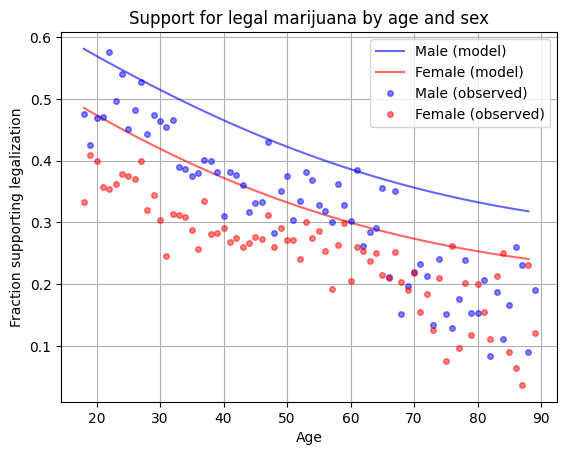

In [12]:
mean_grass = data[["SEX", "GRASS", "AGE"]] \
    .groupby(by=["SEX","AGE"]) \
    .mean() \
    .unstack("SEX")

# Plot model predictions and observed means for each sex on the same plot
pred1.plot(label='Male (model)', color='blue', alpha=0.6)
pred2.plot(label='Female (model)', color='red', alpha=0.6)

# Plot observed means for each sex
mean_grass[('GRASS', 1)].plot(style='o', markersize=4, color='blue', alpha=0.5, label='Male (observed)')
mean_grass[('GRASS', 2)].plot(style='o', markersize=4, color='red', alpha=0.5, label='Female (observed)')

plt.xlabel('Age')
plt.ylabel('Fraction supporting legalization')
plt.title('Support for legal marijuana by age and sex')
plt.legend()
plt.grid()
plt.show()

## Boostrap sampling

Now let's implement the method characterized as non-parametric, which is based on bootstrap resampling.
The following function samples the rows of the `DataFrame` with replacement and runs the regression model on the resampled data.

In [13]:
options = dict(disp=False, start_params=result_hat.params, tol=1e-3) 

def bootstrap(i):
    bootstrapped = data.sample(n=len(data), replace=True)
    results = smf.logit(formula, data=bootstrapped).fit(**options)
    return results.params

The options sent to `fit` make it run faster, but don't affect the results by much.

Each time we run this process, the result represents a single draw from the sampling distribution of the parameters.

In [14]:
bootstrap(0)

Intercept     -1.535994
C(SEX)[T.2]   -0.339957
AGE           -0.031565
AGE2           0.000159
EDUC           0.180206
EDUC2         -0.002019
dtype: float64

By running it many times, we generate a sample from the sampling distribution. `pqdm` runs the sampling process in multiple threads.

In [15]:
try:
    from pqdm.threads import pqdm
except ImportError:
    %pip install pqdm
    from pqdm.threads import pqdm

In [ ]:
estimates = pqdm(range(101), bootstrap, n_jobs=12)
sampling_dist = pd.DataFrame(estimates)
sampling_dist.head()

Here's what the sampling distribution looks like for one of the parameters.

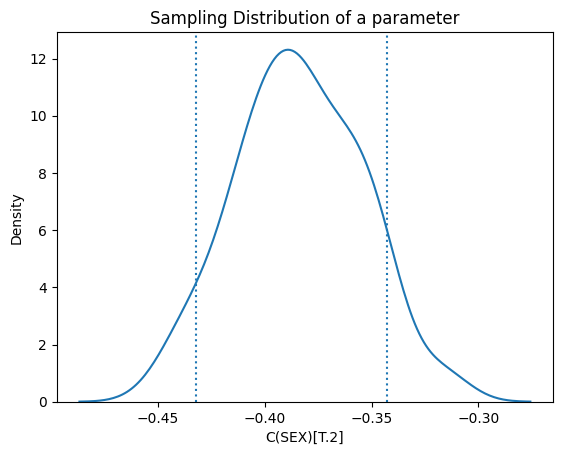

In [17]:
ci90 = sampling_dist['C(SEX)[T.2]'].quantile([0.05, 0.95])
sns.kdeplot(sampling_dist['C(SEX)[T.2]'])
[plt.axvline(x, ls=':') for x in ci90]
plt.title('Sampling Distribution of a parameter');

The mean of the sampling distribution should be close to the parameters we estimated with the original dataset, and it is.

In [18]:
pd.DataFrame({"Sampling mean": sampling_dist.mean(), "Estimates": result_hat.params})

,Sampling mean,Estimates
Intercept,-1.676911,-1.678838
C(SEX)[T.2],-0.383943,-0.384919
AGE,-0.027914,-0.027825
AGE2,0.000116,0.000116
EDUC,0.199711,0.200002
EDUC2,-0.002835,-0.002855


The standard deviations of the sampling distributions should be close to the standard errors computed by StatsModels, and they are.
Most of them are close enough that the difference probably doesn't matter in practice.

In [19]:
def standard_errors(sampling_dist, result_hat):
    df = pd.DataFrame({"Sampling std": sampling_dist.std(), 
                       "Standard error": result_hat.bse})
    num, den = df.values.T
    df['Relative % diff'] = (num / den - 1) * 100
    return df

In [20]:
standard_errors(sampling_dist, result_hat)

,Sampling std,Standard error,Relative % diff
Intercept,0.256702,0.240243,6.851202
C(SEX)[T.2],0.029428,0.031057,-5.244516
AGE,0.004754,0.005153,-7.747785
AGE2,0.000048,0.000053,-9.499461
EDUC,0.035252,0.031193,13.014428
EDUC2,0.001316,0.001166,12.879839


Of course, there is nothing magic about the standard errors computed by StatsModels; they are approximations based on a model of the sampling process, just like the results from resampling.

## The Resampling Framework

To understand what we just did, it is helpful to remember why we did it.
The purpose of the sampling distribution is to quantify the variability in an estimate due to random sampling. It is the answer to the question, "If we ran this sampling process many times, how much would we expect the results to vary?"

To answer that question, we need a model of the sampling process. We use the model to simulate the sampling process and generate counterfactual datasets that represent other samples the process could have generated.

The following figure represents this framework.

<img src="https://github.com/AllenDowney/ElementsOfDataScience/raw/master/figs/resampling.png" width="500">

In bootstrap resampling, we treat the rows of the original dataset as if they are the population and draw a random sample from it.

We use this simulated data to compute the sample statistic; in this example, it's the parameters of the logistic regression model.
We collect the results to form a sample from the sampling distribution, which we can use to compute confidence intervals and standard errors.

This way of simulating the sampling process asks, in effect, what would have happened if we had surveyed different people.
But that's not the only possible model of the sampling process.
An alternative is to ask what would happen if we surveyed the same people, but they gave different answers.
That's the model that underlies the parametric method.

## Parametric bootstrap

So, how do we simulate a sampling process where we survey the same people, but they give different answers?
One way is to assume, for the purposes of the simulation, that the parameters we estimated from the original data are correct.
If so, we can use the regression model to compute the predicted probability for each respondent, like this:

In [21]:
pi_hat = result_hat.predict(data)
pi_hat.describe()

count    20475.000000
mean         0.317167
std          0.113654
min          0.025989
25%          0.234792
50%          0.317927
75%          0.400791
max          0.630366
dtype: float64

Now we can use these probabilities to generate a biased coin toss for each respondent.

In [22]:
simulated = bernoulli.rvs(pi_hat.values)
simulated.mean()

np.float64(0.317020757020757)

Then we can run the regression model with these simulated values as the dependent variable.
The following function shows how.

In [23]:
def bootstrap2(i):
    flipped = data.assign(GRASS=bernoulli.rvs(pi_hat.values))
    results = smf.logit(formula, data=flipped).fit(**options)
    return results.params

Again, the result from a single simulation is a random value from the sampling distribution.

In [24]:
bootstrap2(0)

Intercept     -2.137392
C(SEX)[T.2]   -0.401046
AGE           -0.025988
AGE2           0.000108
EDUC           0.252680
EDUC2         -0.004597
dtype: float64

If we run it many times, we get a sample from the sampling distribution.

In [ ]:
estimates = pqdm(range(101), bootstrap2, n_jobs=12)

In [26]:
sampling_dist2 = pd.DataFrame(estimates)
sampling_dist2.head()

,Intercept,C(SEX)[T.2],AGE,AGE2,EDUC,EDUC2
0,-1.407599,-0.407686,-0.022680,0.000061,0.154234,-0.001492
1,-1.723979,-0.384110,-0.035692,0.000201,0.223715,-0.003449
2,-1.661663,-0.400048,-0.026729,0.000093,0.200555,-0.002832
3,-2.001848,-0.374987,-0.035351,0.000199,0.267622,-0.005294
4,-1.705931,-0.414642,-0.025310,0.000070,0.202859,-0.002968


Here's the sampling distribution for a single parameter.

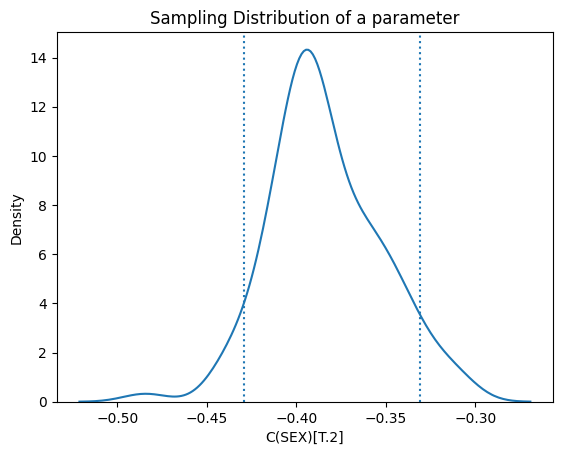

In [27]:
ci90 = sampling_dist2['C(SEX)[T.2]'].quantile([0.05, 0.95])
sns.kdeplot(sampling_dist2['C(SEX)[T.2]'])
[plt.axvline(x, ls=':') for x in ci90]
plt.title('Sampling Distribution of a parameter');

Again, the standard deviations should be close to the standard errors, and they are.

In [28]:
standard_errors(sampling_dist2, result_hat)

,Sampling std,Standard error,Relative % diff
Intercept,0.256730,0.240243,6.862722
C(SEX)[T.2],0.030870,0.031057,-0.600324
AGE,0.005579,0.005153,8.259584
AGE2,0.000058,0.000053,9.124203
EDUC,0.029696,0.031193,-4.797006
EDUC2,0.001068,0.001166,-8.400494


So we have two models of the sampling process that yield different sampling distributions. But these are not the only models.

If the first method asks, "What if we surveyed different people?" and the second asks "What if we surveyed the same people and they gave different answers?", let's consider a third method that asks "¿Por qué no los dos?".

## The Hybrid Model

The following function uses bootstrap sampling to simulate surveying different people; then it uses the parametric method to simulate their responses.

In [29]:
def bootstrap3(i):
    bootstrapped = data.sample(n=len(data), replace=True)
    pi_hat = result_hat.predict(bootstrapped)
    flipped = bootstrapped.assign(GRASS=bernoulli.rvs(pi_hat.values))
    results = smf.logit(formula, data=flipped).fit(**options)
    return results.params

In [30]:
bootstrap3(0)

Intercept     -1.812942
C(SEX)[T.2]   -0.369212
AGE           -0.028515
AGE2           0.000127
EDUC           0.211837
EDUC2         -0.003133
dtype: float64

In [ ]:
estimates = pqdm(range(101), bootstrap3, n_jobs=12)

In [32]:
sampling_dist3 = pd.DataFrame(estimates)
sampling_dist3.head()

,Intercept,C(SEX)[T.2],AGE,AGE2,EDUC,EDUC2
0,-1.596145,-0.400772,-0.027094,0.000102,0.190017,-0.002549
1,-1.548812,-0.400642,-0.019345,0.000019,0.162548,-0.001833
2,-1.852160,-0.370509,-0.031722,0.000160,0.233875,-0.004018
3,-1.542110,-0.415720,-0.032228,0.000175,0.192384,-0.002687
4,-1.786455,-0.384412,-0.025379,0.000108,0.198280,-0.002545


Here's the sampling distribution for one of the parameters.

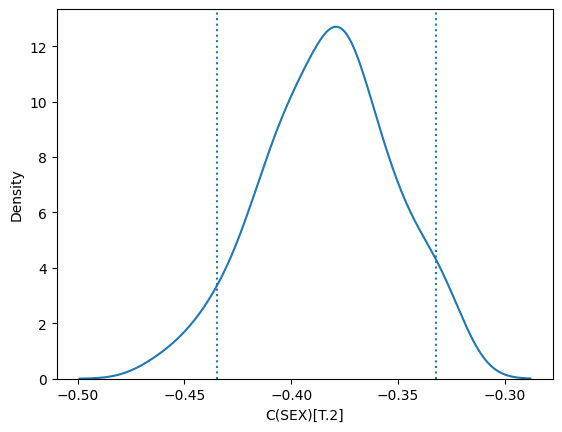

In [33]:
ci90 = sampling_dist3['C(SEX)[T.2]'].quantile([0.05, 0.95])
sns.kdeplot(sampling_dist3['C(SEX)[T.2]'])
[plt.axvline(x, ls=':') for x in ci90];

Again, the standard errors are comparable to the ones computed by StatsModels.

In [34]:
standard_errors(sampling_dist3, result_hat)

,Sampling std,Standard error,Relative % diff
Intercept,0.220652,0.240243,-8.154763
C(SEX)[T.2],0.030231,0.031057,-2.656978
AGE,0.005145,0.005153,-0.164107
AGE2,0.000054,0.000053,2.205439
EDUC,0.029728,0.031193,-4.695702
EDUC2,0.001122,0.001166,-3.712970


Now we have four ways to compute sampling distributions, confidence intervals, and standard errors, and they yield different results. So you might wonder...

## Which One Is Right?

None of them are right.
They are based on different models of the sampling process, so they quantify different sources of uncertainty.

In some cases we might find that different methods converge on the same results, asymptotically, under certain assumptions.
But that doesn't really matter, because with finite data sets, the results are not generally the same.
So the important question is whether the difference are big enough to matter in practice.

In this example, it is easy to implement multiple models and compare the results. If they were substantially different, we would need to think more carefully about the modeling assumptions they are based on and choose the one we think is the best description of the data-generating process.

But in this example, the differences are small enough that they probably don't matter in practice.
So we are free to choose whichever is easiest to implement, or fastest to compute, or convenient in some other way.

It is a common error to presume that the result of an analytic method is uniquely correct, and that results from computational methods like resampling are approximations to it.
Analytic methods are often fast to compute, but they are always based on modeling assumptions and usually based on approximations, so they are no more correct than computational methods.

Copyright Allen Downey

Updated by [Tiniaco Leyba](https://tiniacoleyba.com/) in May 2025

[Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)